### Phase 1: Data Exploration & Cleaning

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv')

# Convert Date to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("---------Null Values---------")
print(df.isnull().sum())

# Ensure Total Sales is numeric (Price * Quantity)
df['Total Sales'] = df['Quantity'] * df['Price']

---------Null Values---------
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [20]:
### Phase 2: Basic Analysis & Pattern Finding

In [21]:
# Monthly Trends
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].sum()

# Top Products
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

# Region Performance
region_share = df.groupby('Region')['Total_Sales'].sum()

In [22]:
### Phase 3: Drafting Visuals

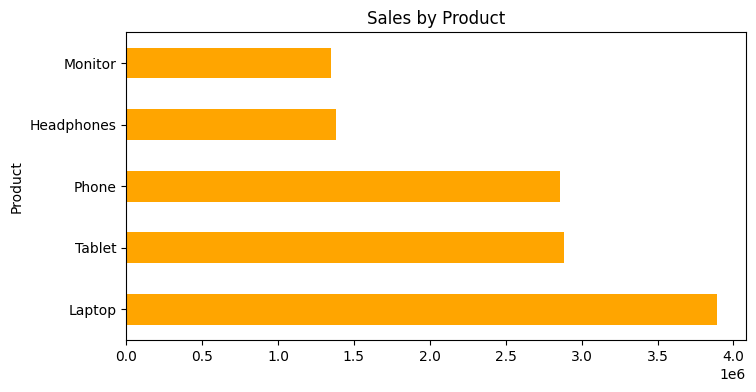

In [25]:
plt.figure(figsize=(8,4))
top_products.plot(kind='barh', color='orange')
plt.title('Sales by Product')
plt.show()

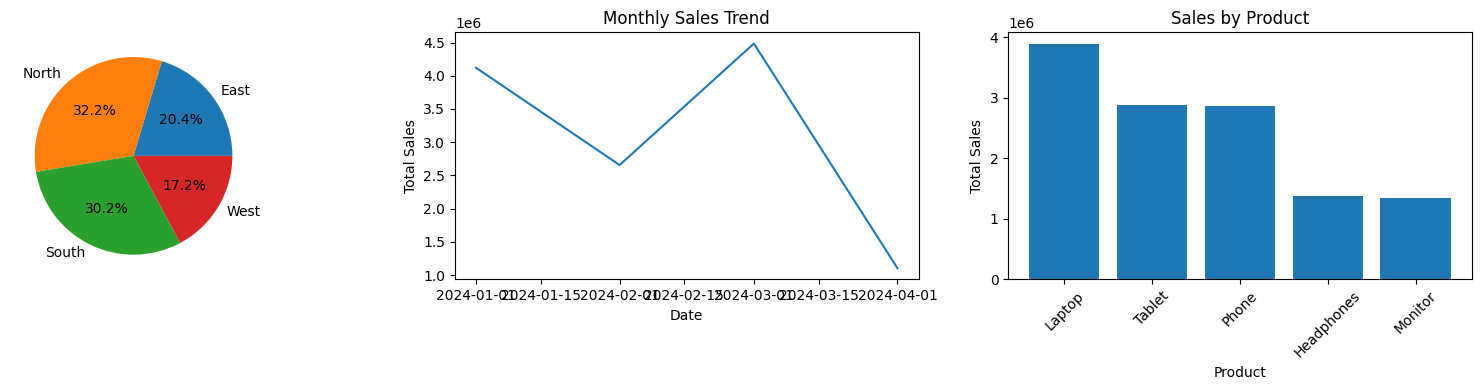

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

region_share = df.groupby('Region')['Total_Sales'].sum()

axes[0].pie(region_share.values, labels=region_share.index, autopct='%1.1f%%')
axes[2].set_title('Sales by Region')

# ---------- Line Chart (Monthly Sales Trend) ----------
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

axes[1].plot(monthly_sales.index, monthly_sales.values)
axes[1].set_title('Monthly Sales Trend')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')

# ---------- Bar Chart (Top Products) ----------
top_products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)

axes[2].bar(top_products.index, top_products.values)
axes[2].set_title('Sales by Product')
axes[2].set_xlabel('Product')
axes[2].set_ylabel('Total Sales')
axes[2].tick_params(axis='x', rotation=45)

# ---------- Pie Chart (Region Share) ----------


plt.tight_layout()
plt.show()
